In [1]:
import pandas as pd
import numpy as np
import sys
from scipy.signal import chirp
sys.path.append("..")
# from joblib import Parallel, delayed
# from multitaper.mtspec import spectrogram
# from tqdm import tqdm

from multitaper_toolbox.python.multitaper_spectrogram_python import multitaper_spectrogram

from Src.data_modules import *

In [2]:
train_data, train_target = load_train_data()

# Multitaper

Window length   2.0s and overlap 50%
Total number of spectral estimates 8
Frequency band of interest ( 0.00-125.00)Hz
Total frequency points 502
Dimensions de spec : (8,)
Dimensions de time : 502
Dimensions de freq : 502


TypeError: Incompatible X, Y inputs to pcolormesh; see help(pcolormesh)

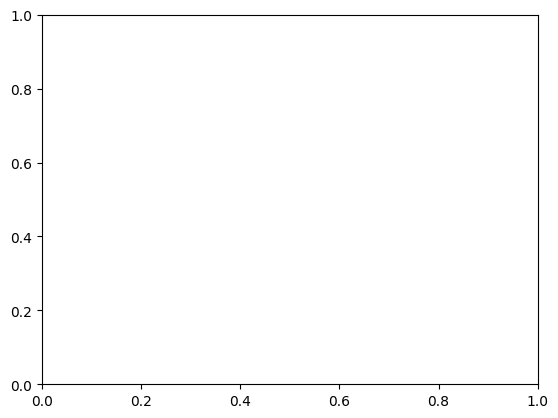

In [11]:
from multitaper.mtspec import spectrogram
import numpy as np
import matplotlib.pyplot as plt

# Signal synthétique
sfreq = 250  # Fréquence d'échantillonnage
duration = 10  # Durée en secondes
t = np.linspace(0, duration, sfreq * duration)
signal = np.sin(2 * np.pi * 10 * t)  # Signal sinusoïdal de 10 Hz

# Calcul multitaper
spec, time, freq, _ = spectrogram(
    signal, 
    dt=1/sfreq, 
    twin=2.0, 
    olap=0.5, 
    nw=3.5, 
    kspec=5
)

# Vérification des dimensions
print("Dimensions de spec :", spec.shape)
print("Dimensions de time :", len(time))
print("Dimensions de freq :", len(freq))

# Reshaping spec si nécessaire pour qu'il ait les dimensions attendues
if spec.ndim == 1:
    spec = np.expand_dims(spec, axis=0)

# Correction pour l'affichage
if spec.ndim == 2:  # S'assurer que spec est bien 2D
    plt.pcolormesh(time, freq, spec.T, shading='auto')  # Utilisez 'auto' pour éviter les erreurs
    plt.colorbar(label='Puissance Spectrale')
    plt.xlabel('Temps (s)')
    plt.ylabel('Fréquence (Hz)')
    plt.title('Multitaper Spectrogram')
    plt.show()
else:
    print("Le spectrogramme n'a pas les dimensions attendues.")


In [4]:
# Simuler des données EEG (par exemple : 5 canaux, 10 secondes de données à 250 Hz)
sampling_rate = 250  # Hz
n_channels = 5
duration = 10  # secondes
n_samples = sampling_rate * duration
#data = np.random.randn(n_channels, n_samples)  # Exemple de données synthétiques

# Paramètres pour la fonction spectrogram
dt = 1 / sampling_rate  # Intervalle de temps entre les échantillons
twin = 1  # Taille des fenêtres en secondes

In [8]:
# Fonction de calcul du spectrogramme pour un canal
def compute_spectrogram(channel_data, dt, twin):
    spec, time, freq, _ = spectrogram(
        channel_data,
        dt=dt,
        twin=twin,
        olap=0.5,
        nw=1,
        kspec=2,
        fmin=5.0,
        fmax=30.0,
        iadapt=0
    )
    return spec, time, freq

# Parallélisation avec affichage de la progression
results = Parallel(n_jobs=-1)(
    delayed(compute_spectrogram)(channel_data, dt, twin) 
    for channel_data in tqdm(train_data, total=n_channels, desc="Traitement des canaux", ncols=100)
)

# Affichage des résultats
for i, (spec, time, freq) in enumerate(results):
    print(f"Spectrogramme du canal {i + 1} :")
    print("Temps :", time)
    print("Fréquences :", freq)
    print("Spectre :", spec)

Traitement des canaux: 100%|██████████████████████████████████████████████████| 5/5 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Exemple de visualisation pour un canal
plt.pcolormesh(time, freq, 10 * np.log10(spec.T), shading='auto')
plt.ylabel('Fréquence (Hz)')
plt.xlabel('Temps (s)')
plt.title('Spectrogramme')
plt.colorbar(label='Puissance (dB)')
plt.show()

NameError: name 'time' is not defined

# Multitaper_toolbox

## Exemple

Multitaper Spectrogram Properties: 
     Spectral Resolution: 2.0Hz
     Window Length: 2.0s
     Window Step: 0.5s
     Time Half-Bandwidth Product: 2
     Number of Tapers: 3
     Frequency Range: 0-25Hz
     NFFT: 512
     Detrend: constant


 Multitaper compute time: 1.03 seconds


c:\Users\planc\Documents\Dev_projects\EEG_signals_quality_analysis\Notebooks\..\multitaper_toolbox\python\multitaper_spectrogram_python.py:201: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


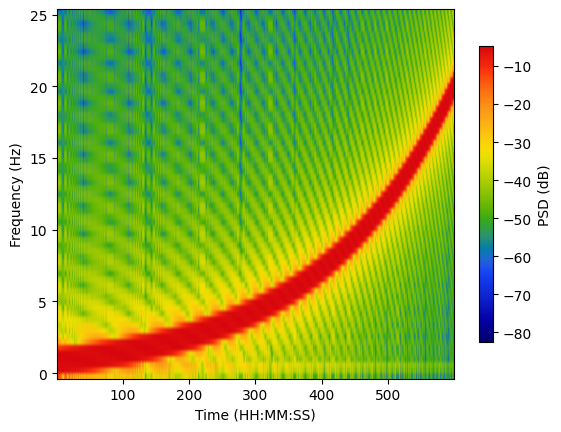

In [3]:
# Set spectrogram params
fs = 200  # Sampling Frequency
frequency_range = [0, 25]  # Limit frequencies from 0 to 25 Hz
time_bandwidth = 2  # Set time-half bandwidth
num_tapers = 3  # Set number of tapers (optimal is time_bandwidth*2 - 1)
window_params = [2, 0.5]  # Window size is 4s with step size of 1s
min_nfft = 0  # No minimum nfft
detrend_opt = 'constant'  # detrend each window by subtracting the average
multiprocess = True  # use multiprocessing
n_jobs = 3  # use 3 cores in multiprocessing
weighting = 'unity'  # weight each taper at 1
plot_on = True  # plot spectrogram
return_fig = False  # do not return plotted spectrogram
clim_scale = False # do not auto-scale colormap
verbose = True  # print extra info
xyflip = False  # do not transpose spect output matrix

# Generate sample chirp data
t = np.arange(1/fs, 600, 1/fs)  # Create 10 min time array from 1/fs to 600 stepping by 1/fs
f_start = 1  # Set chirp freq range min (Hz)
f_end = 20  # Set chirp freq range max (Hz)
data = chirp(t, f_start, t[-1], f_end, 'logarithmic')

# Compute the multitaper spectrogram
spect, stimes, sfreqs = multitaper_spectrogram(data, fs, frequency_range, time_bandwidth, num_tapers, window_params, min_nfft, detrend_opt, multiprocess, n_jobs,
                                               weighting, plot_on, return_fig, clim_scale, verbose, xyflip)

## True data

In [ ]:
plot_signals_analysis(train_data, train_target, start_time=500)

Multitaper Spectrogram Properties: 
     Spectral Resolution: 2.0Hz
     Window Length: 5.0s
     Window Step: 1.0s
     Time Half-Bandwidth Product: 5
     Number of Tapers: 9
     Frequency Range: 0-30Hz
     NFFT: 2048
     Detrend: linear


 Multitaper compute time: 2.43 seconds


In [4]:
np.linspace(0,10,5)

array([ 0. ,  2.5,  5. ,  7.5, 10. ])